In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.datasets import make_regression
from sklearn import tree
import statsmodels.api as sm

pd.set_option("display.max_columns", None)

#Cargar datos

In [ ]:
df1 = pd.read_csv("new_data.csv")

print("Filas y columnas:", df1.shape)
df1.head()

Filas y columnas: (419, 28)


,Date,Site ID,POC,Daily Max CO Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,AQS Parameter Code,AQS Parameter Description,Method Code,Method Description,CBSA Code,CBSA Name,Site Latitude,Site Longitude,Dominant Source,Elevation (m),Measurement Scale,Measurement Scale Definition,Monitor Type,Monitoring Agency,Monitoring Objective,NAAQS Primary Monitor?,Networks,Probe Height (m),QA Primary Monitor?
0,2023-01-01,10730023,2,0.2,Parts per million,2,North Birmingham,19,79,42101,Carbon monoxide,93,INSTRUMENTAL - GAS FILTER CORRELATION CO ANALYZER,13820,"Birmingham-Hoover, AL",33.553056,-86.815,POINT,177.0,NEIGHBORHOOD,500 M TO 4KM,SLAMS,"Jefferson County, AL Department Of Health",OTHER,NaN,NCORE,17.5,NaN
1,2023-01-02,10730023,2,0.3,Parts per million,3,North Birmingham,24,100,42101,Carbon monoxide,93,INSTRUMENTAL - GAS FILTER CORRELATION CO ANALYZER,13820,"Birmingham-Hoover, AL",33.553056,-86.815,POINT,177.0,NEIGHBORHOOD,500 M TO 4KM,SLAMS,"Jefferson County, AL Department Of Health",OTHER,NaN,NCORE,17.5,NaN
2,2023-01-03,10730023,2,0.2,Parts per million,2,North Birmingham,24,100,42101,Carbon monoxide,93,INSTRUMENTAL - GAS FILTER CORRELATION CO ANALYZER,13820,"Birmingham-Hoover, AL",33.553056,-86.815,POINT,177.0,NEIGHBORHOOD,500 M TO 4KM,SLAMS,"Jefferson County, AL Department Of Health",OTHER,NaN,NCORE,17.5,NaN
3,2023-01-04,10730023,2,0.5,Parts per million,6,North Birmingham,24,100,42101,Carbon monoxide,93,INSTRUMENTAL - GAS FILTER CORRELATION CO ANALYZER,13820,"Birmingham-Hoover, AL",33.553056,-86.815,POINT,177.0,NEIGHBORHOOD,500 M TO 4KM,SLAMS,"Jefferson County, AL Department Of Health",OTHER,NaN,NCORE,17.5,NaN
4,2023-01-05,10730023,2,0.6,Parts per million,7,North Birmingham,10,42,42101,Carbon monoxide,93,INSTRUMENTAL - GAS FILTER CORRELATION CO ANALYZER,13820,"Birmingham-Hoover, AL",33.553056,-86.815,POINT,177.0,NEIGHBORHOOD,500 M TO 4KM,SLAMS,"Jefferson County, AL Department Of Health",OTHER,NaN,NCORE,17.5,NaN


In [ ]:
df1.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 419 entries, 0 to 418
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Date                          419 non-null    object 
 1   Site ID                       419 non-null    int64  
 2   POC                           419 non-null    int64  
 3   Daily Max CO Concentration    419 non-null    float64
 4   Units                         419 non-null    object 
 5   Daily AQI Value               419 non-null    int64  
 6   Local Site Name               419 non-null    object 
 7   Daily Obs Count               419 non-null    int64  
 8   Percent Complete              419 non-null    int64  
 9   AQS Parameter Code            419 non-null    int64  
 10  AQS Parameter Description     419 non-null    object 
 11  Method Code                   419 non-null    int64  
 12  Method Description            419 non-null    object 
 13  CBSA 

In [ ]:
df1.columns

Index(['Date', 'Site ID', 'POC', 'Daily Max CO Concentration', 'Units',
       'Daily AQI Value', 'Local Site Name', 'Daily Obs Count',
       'Percent Complete', 'AQS Parameter Code', 'AQS Parameter Description',
       'Method Code', 'Method Description', 'CBSA Code', 'CBSA Name',
       'Site Latitude', 'Site Longitude', 'Dominant Source', 'Elevation (m)',
       'Measurement Scale', 'Measurement Scale Definition', 'Monitor Type',
       'Monitoring Agency', 'Monitoring Objective', 'NAAQS Primary Monitor?',
       'Networks', 'Probe Height (m)', 'QA Primary Monitor?'],
      dtype='object')

In [ ]:
df1.describe().round(2)

,Site ID,POC,Daily Max CO Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,AQS Parameter Code,Method Code,CBSA Code,Site Latitude,Site Longitude,Elevation (m),NAAQS Primary Monitor?,Probe Height (m),QA Primary Monitor?
count,419.00,419.00,419.00,419.00,419.00,419.00,419.0,419.0,419.0,419.00,419.00,419.00,0.0,359.00,0.0
mean,10730737.89,1.42,0.28,3.09,23.07,96.15,42101.0,93.0,13820.0,33.52,-86.86,179.26,NaN,10.69,NaN
std,706.11,0.49,0.15,1.90,2.96,12.32,0.0,0.0,0.0,0.03,0.05,2.30,NaN,6.76,NaN
min,10730023.00,1.00,0.00,0.00,5.00,21.00,42101.0,93.0,13820.0,33.49,-86.92,177.00,NaN,4.00,NaN
25%,10730023.00,1.00,0.20,2.00,24.00,100.00,42101.0,93.0,13820.0,33.49,-86.92,177.00,NaN,4.00,NaN
50%,10731003.00,1.00,0.30,3.00,24.00,100.00,42101.0,93.0,13820.0,33.52,-86.84,180.00,NaN,4.00,NaN
75%,10731003.00,2.00,0.40,5.00,24.00,100.00,42101.0,93.0,13820.0,33.55,-86.82,180.00,NaN,17.50,NaN
max,10732059.00,2.00,0.80,9.00,24.00,100.00,42101.0,93.0,13820.0,33.55,-86.82,183.73,NaN,17.50,NaN


#Revisar valores faltantes y duplicados

In [ ]:
print("Valores faltantes:")
print(df1.isna().sum().sort_values(ascending=False).head(15))

print("\nFilas duplicadas:", df1.duplicated().sum())

Valores faltantes:
QA Primary Monitor?           419
NAAQS Primary Monitor?        419
Monitor Type                  181
Networks                      181
Probe Height (m)               60
Units                           0
Local Site Name                 0
Daily AQI Value                 0
Date                            0
Site ID                         0
POC                             0
Daily Max CO Concentration      0
Method Code                     0
AQS Parameter Description       0
AQS Parameter Code              0
dtype: int64

Filas duplicadas: 0


#Preparacion de la fecha

In [ ]:
df1["Date"] = pd.to_datetime(df1["Date"])

df1["Year"] = df1["Date"].dt.year
df1["Month"] = df1["Date"].dt.month
df1["Day"] = df1["Date"].dt.day

df1[["Date", "Year", "Month", "Day"]].head()

,Date,Year,Month,Day
0,2023-01-01,2023,1,1
1,2023-01-02,2023,1,2
2,2023-01-03,2023,1,3
3,2023-01-04,2023,1,4
4,2023-01-05,2023,1,5


#Seleccion de variables

In [ ]:
target = "Daily Max CO Concentration"

features = [
    "Daily Obs Count",
    "Percent Complete",
    "Site Latitude",
    "Site Longitude",
    "Elevation (m)",
    "Probe Height (m)"
]

df_model = df1[features + [target]].copy()

for column in features:
    df_model[column] = df_model[column].fillna(df_model[column].median())

print(df_model.shape)
df_model.head()

(419, 7)


,Daily Obs Count,Percent Complete,Site Latitude,Site Longitude,Elevation (m),Probe Height (m),Daily Max CO Concentration
0,19,79,33.553056,-86.815,177.0,17.5,0.2
1,24,100,33.553056,-86.815,177.0,17.5,0.3
2,24,100,33.553056,-86.815,177.0,17.5,0.2
3,24,100,33.553056,-86.815,177.0,17.5,0.5
4,10,42,33.553056,-86.815,177.0,17.5,0.6


#Estadística descriptiva de las variables del modelo

In [ ]:
df_model.describe().round(3)

,Daily Obs Count,Percent Complete,Site Latitude,Site Longitude,Elevation (m),Probe Height (m),Daily Max CO Concentration
count,419.000,419.000,419.000,419.000,419.000,419.000,419.000
mean,23.074,96.153,33.519,-86.862,179.259,9.735,0.282
std,2.964,12.319,0.031,0.047,2.297,6.681,0.152
min,5.000,21.000,33.486,-86.915,177.000,4.000,0.000
25%,24.000,100.000,33.486,-86.915,177.000,4.000,0.200
50%,24.000,100.000,33.521,-86.844,180.000,4.000,0.300
75%,24.000,100.000,33.553,-86.815,180.000,17.500,0.400
max,24.000,100.000,33.553,-86.815,183.726,17.500,0.800


#Histogramas

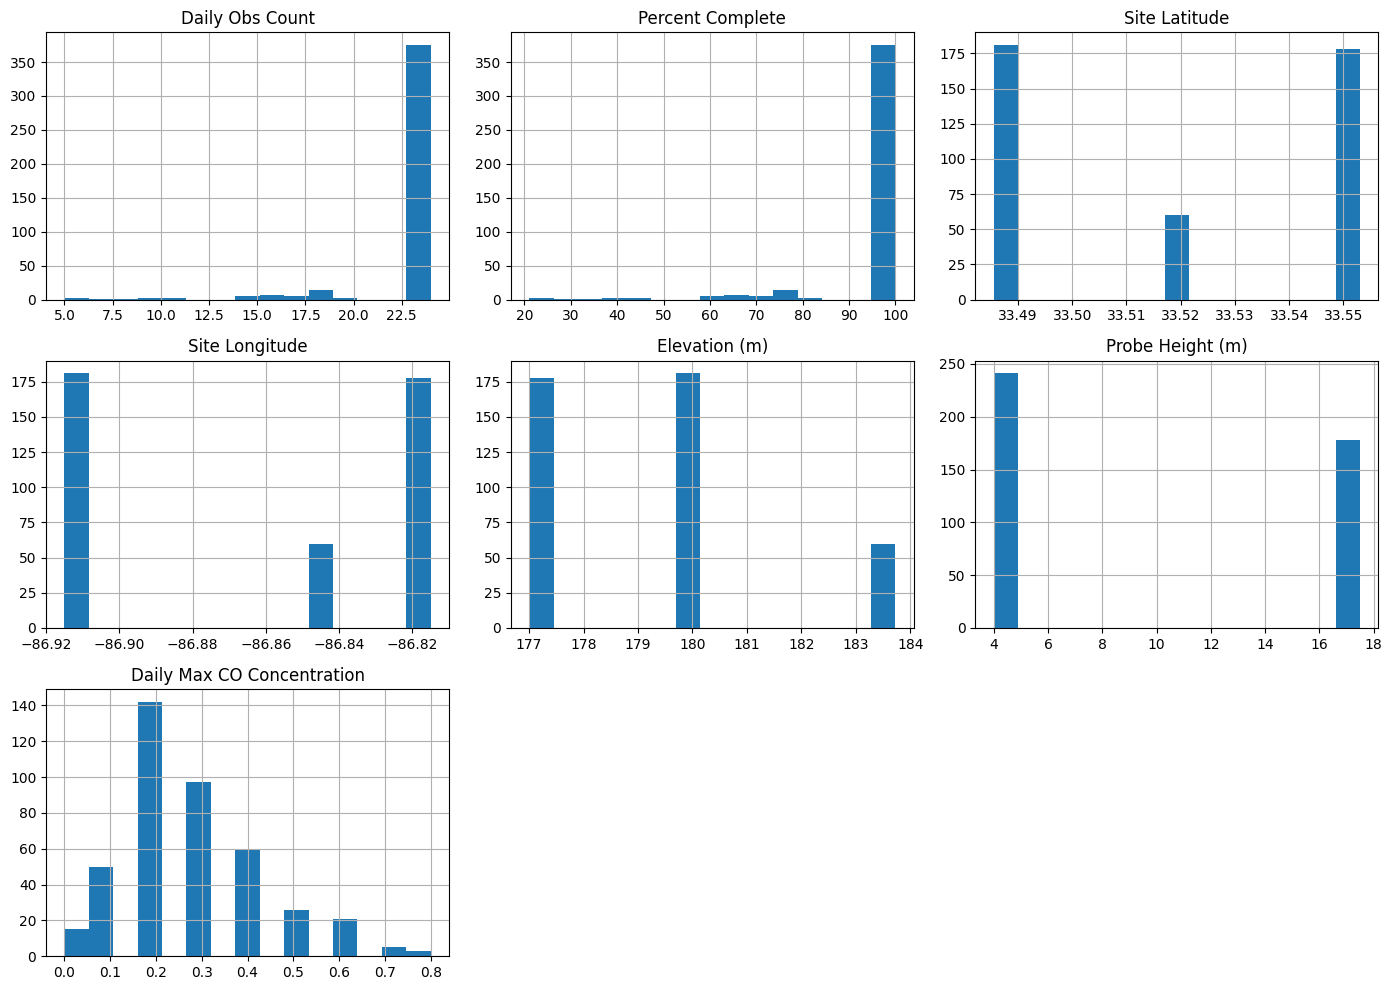

In [ ]:
df_model.hist(figsize=(14, 10), bins=15)
plt.tight_layout()
plt.show()

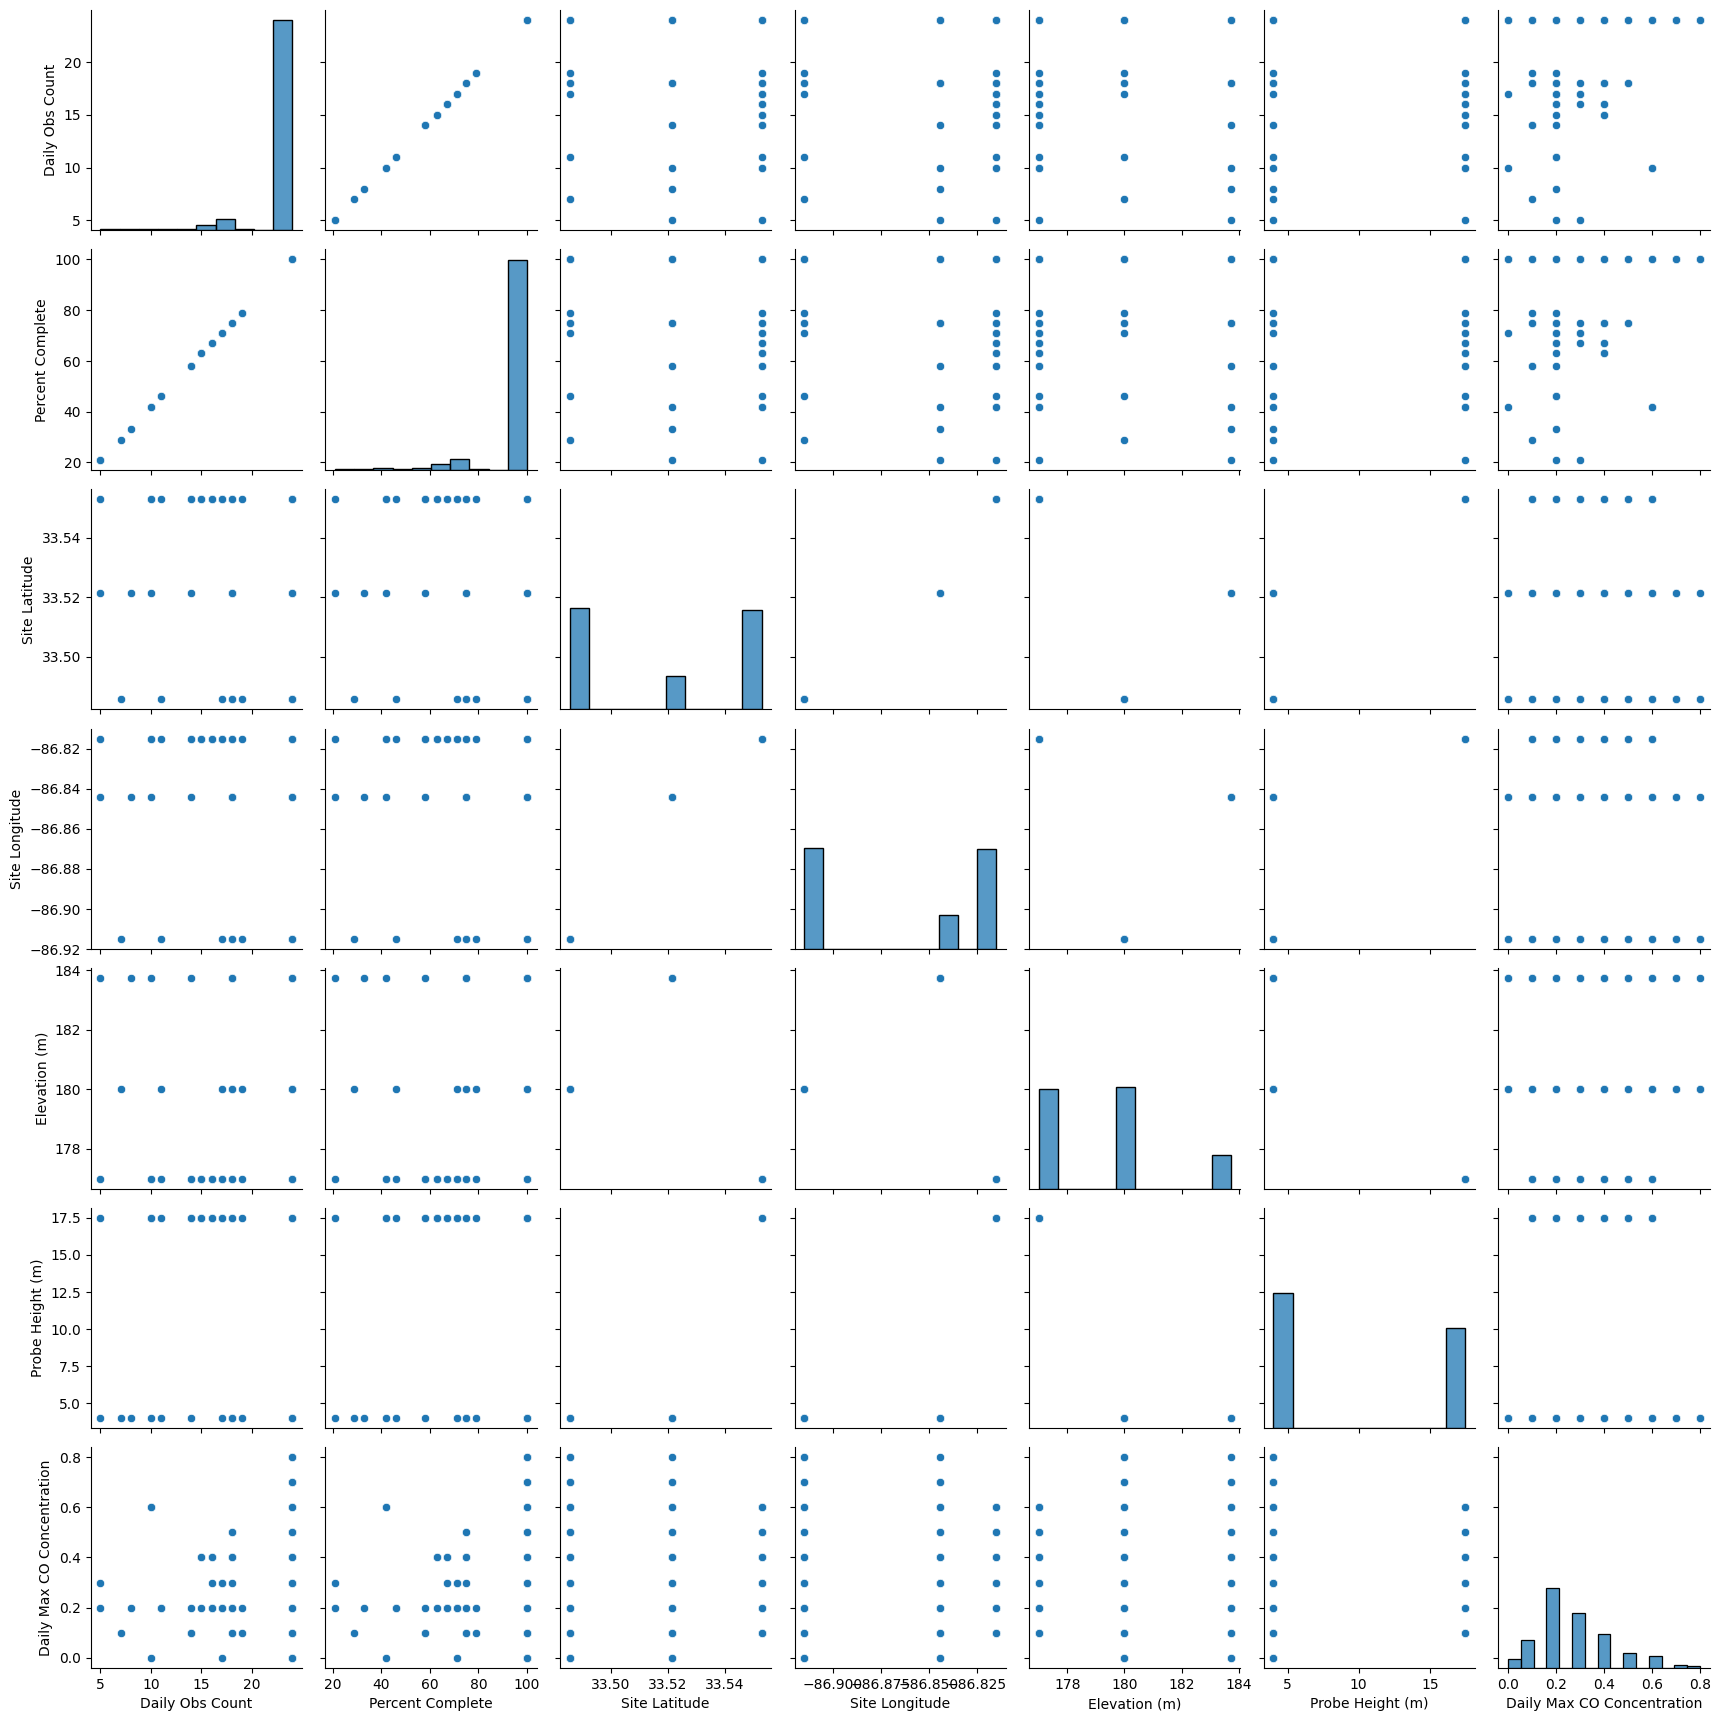

In [ ]:
sns.pairplot(df_model)
plt.show()

#Matriz de Correlacion

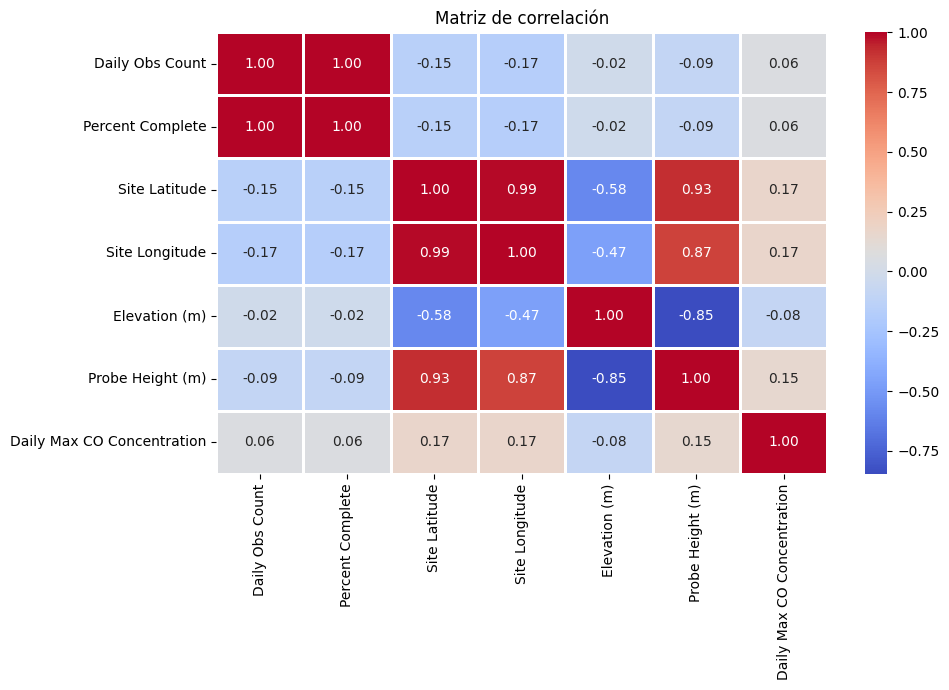

In [ ]:
numeric_df1 = df_model.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 7))
sns.heatmap(
    numeric_df1.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=1,
    fmt=".2f"
)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

#Preparar para regresion lineal

In [ ]:
x = df_model[features]
y = df_model[target]

print("X:", x.shape)
print("y:", y.shape)

X: (419, 6)
y: (419,)


#Dividir los datos en entrenamiento y prueba

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.30,
    random_state=123
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (293, 6)
Datos de prueba: (126, 6)


#Crear y entrenar regresion lineal

In [ ]:
lm = LinearRegression()

lm.fit(X_train, y_train)

print("Intercepto:", lm.intercept_)

coeficientes = pd.DataFrame({
    "Variable": features,
    "Coeficiente": lm.coef_
})

coeficientes

Intercepto: -1.7112465808312864


,Variable,Coeficiente
0,Daily Obs Count,-0.767979
1,Percent Complete,0.185398
2,Site Latitude,0.000141
3,Site Longitude,0.000264
4,Elevation (m),0.010297
5,Probe Height (m),0.005832


#Realizar predicciones

In [ ]:
predictions = lm.predict(X_test)

resultados = pd.DataFrame({
    "Real": y_test.values,
    "Predicho": predictions
})

resultados.head(10)

,Real,Predicho
0,0.2,0.303439
1,0.2,0.303439
2,0.5,0.303439
3,0.2,0.255566
4,0.6,0.303439
5,0.5,0.266880
6,0.2,0.255566
7,0.2,0.303439
8,0.2,0.275676
9,0.6,0.293955


#Evaluar el modelo

In [ ]:
mse = metrics.mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
mae = metrics.mean_absolute_error(y_test, predictions)
r2 = metrics.r2_score(y_test, predictions)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

MSE : 0.02077533603674818
RMSE: 0.14413651874784605
MAE : 0.11604860860715609
R²  : 0.05398183014652469


#Grafico CO real vs CO predicho

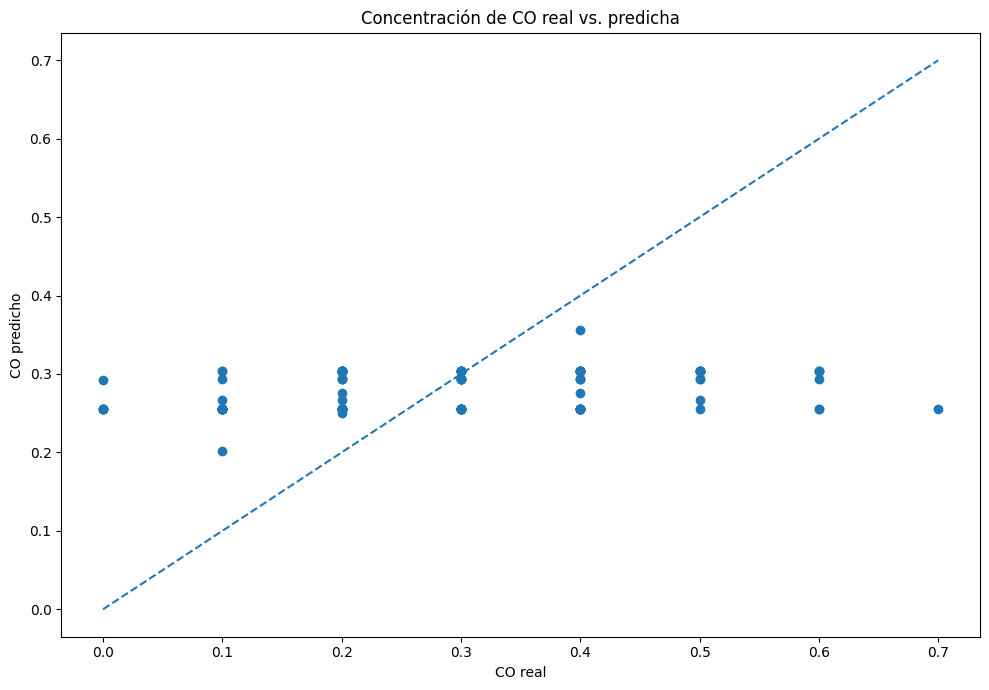

In [ ]:
plt.figure(figsize=(10, 7))
plt.scatter(y_test, predictions)
plt.xlabel("CO real")
plt.ylabel("CO predicho")
plt.title("Concentración de CO real vs. predicha")

min_value = min(y_test.min(), predictions.min())
max_value = max(y_test.max(), predictions.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.tight_layout()
plt.show()

#Analisis de residuos

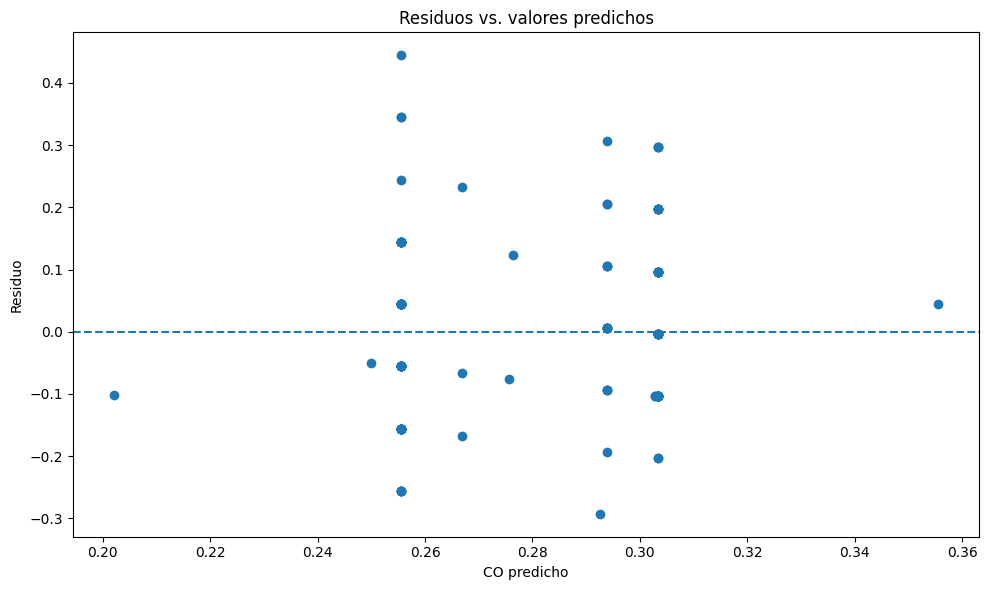

In [ ]:
residuos = y_test.values - predictions

plt.figure(figsize=(10, 6))
plt.scatter(predictions, residuos)
plt.axhline(0, linestyle="--")
plt.xlabel("CO predicho")
plt.ylabel("Residuo")
plt.title("Residuos vs. valores predichos")
plt.tight_layout()
plt.show()

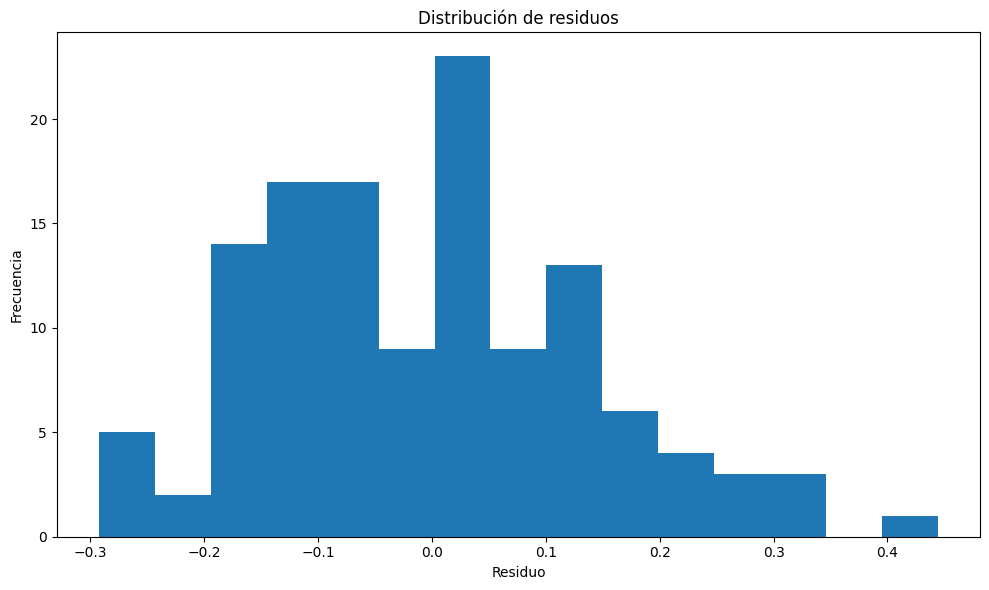

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(residuos, bins=15)
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.title("Distribución de residuos")
plt.tight_layout()
plt.show()

#Generacion de datos artificiales

In [ ]:
X, y_artificial, coef = make_regression(
    n_samples=100,
    n_features=6,
    n_informative=3,
    random_state=20,
    shuffle=False,
    noise=20,
    coef=True
)

print("X:", X.shape)
print("y:", y_artificial.shape)
print("Coeficientes reales:", coef)

X: (100, 6)
y: (100,)
Coeficientes reales: [78.58638696 97.72361019 52.30606265  0.          0.          0.        ]


In [ ]:
df_artificial = pd.DataFrame(
    X,
    columns=["X1", "X2", "X3", "X4", "X5", "X6"]
)

df_artificial["y"] = y_artificial

df_artificial.head()

,X1,X2,X3,X4,X5,X6,y
0,0.883893,0.195865,0.357537,-2.343262,-1.084833,0.559696,109.512132
1,0.939469,-0.978481,0.503097,0.406414,0.323461,-0.493411,52.542242
2,-0.792017,-0.842368,-1.279503,0.245715,-0.044195,1.567633,-247.679018
3,1.051109,0.406368,-0.168646,-3.189703,1.120132,1.332778,98.678111
4,-0.243339,-0.130031,-0.109017,1.556186,0.128778,-2.066949,-55.286890


#Regresion con los datos artificiales

In [ ]:
X_train_art, X_test_art, y_train_art, y_test_art = train_test_split(
    X,
    y_artificial,
    test_size=0.30,
    random_state=123
)

lm_art = LinearRegression()
lm_art.fit(X_train_art, y_train_art)

pred_art = lm_art.predict(X_test_art)

print("Intercepto:", lm_art.intercept_)
print("Coeficientes:", lm_art.coef_)
print("MSE:", metrics.mean_squared_error(y_test_art, pred_art))
print("R²:", metrics.r2_score(y_test_art, pred_art))

Intercepto: -5.34975730017766
Coeficientes: [79.36840993 95.0744505  55.84937043 -1.81202698  1.46107742 -4.0380858 ]
MSE: 426.43419398159045
R²: 0.9755834349278146


#Arbol de decision

In [ ]:
tree_model = tree.DecisionTreeRegressor(
    max_depth=5,
    random_state=10
)

tree_model.fit(X_train_art, y_train_art)

test_pred = tree_model.predict(X_test_art)

print("MSE del árbol:", metrics.mean_squared_error(y_test_art, test_pred))
print("R² del árbol:", metrics.r2_score(y_test_art, test_pred))

MSE del árbol: 7931.574768958281
R² del árbol: 0.545857686357267


#Importancia de las caracteristicas

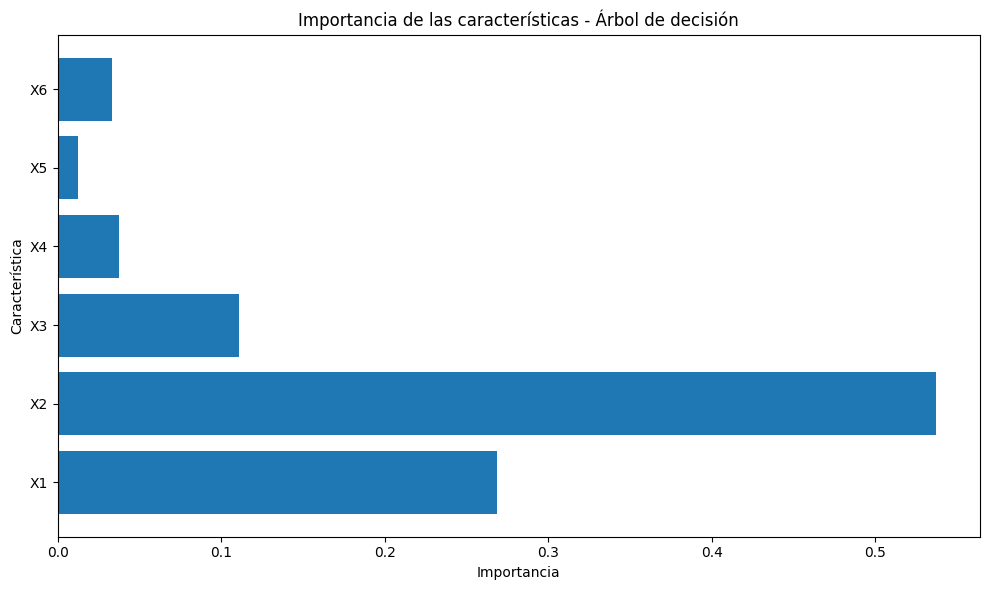

In [ ]:
n_features = X.shape[1]

plt.figure(figsize=(10, 6))
plt.barh(
    range(n_features),
    tree_model.feature_importances_
)
plt.yticks(
    range(n_features),
    ["X1", "X2", "X3", "X4", "X5", "X6"]
)
plt.xlabel("Importancia")
plt.ylabel("Característica")
plt.title("Importancia de las características - Árbol de decisión")
plt.tight_layout()
plt.show()

#Visualizar el arbol de decision

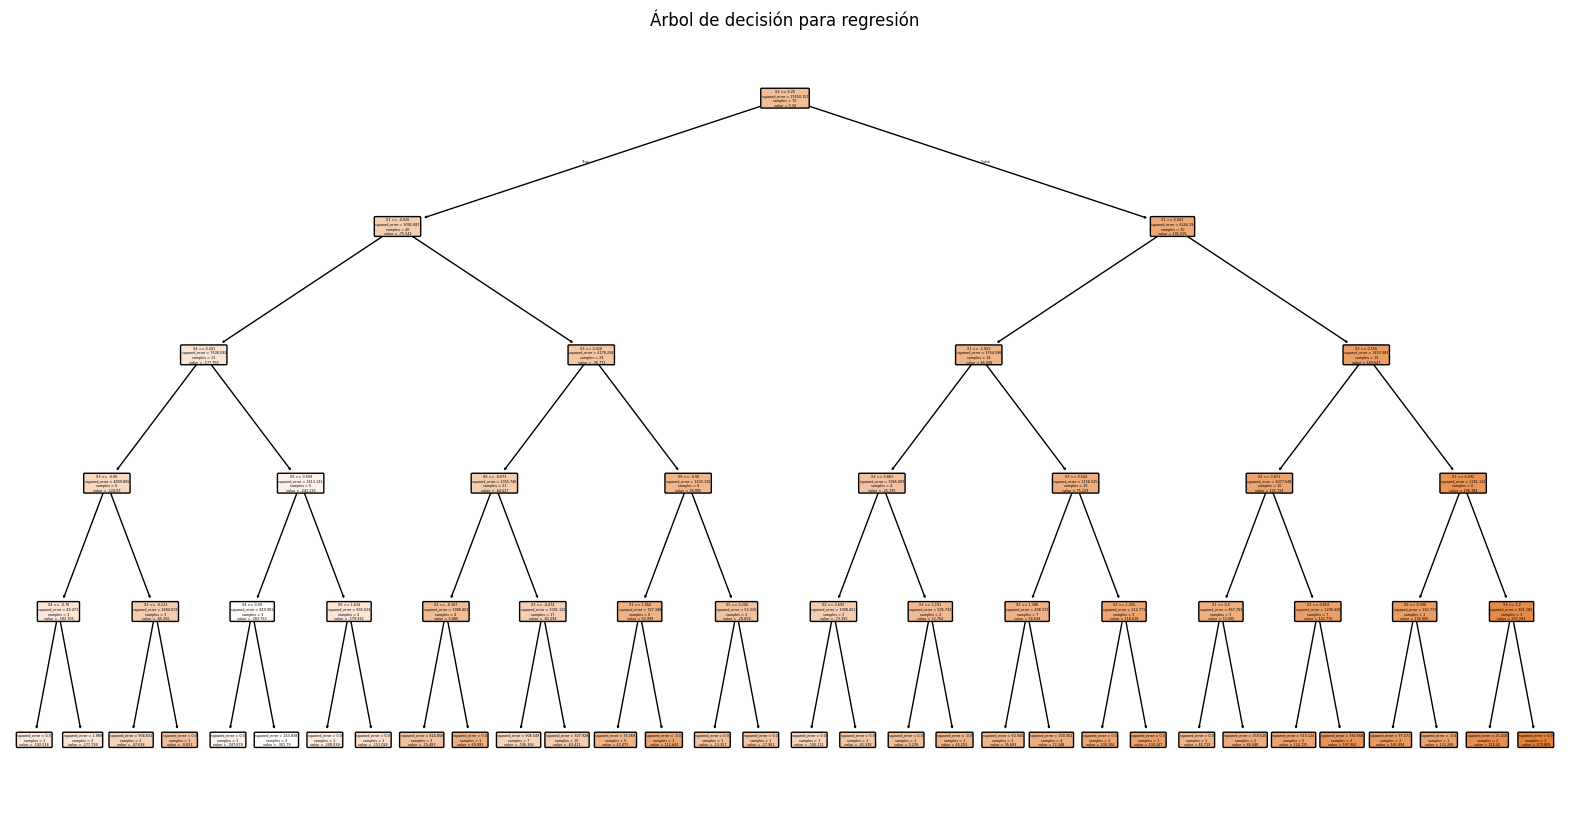

In [ ]:
plt.figure(figsize=(20, 10))

tree.plot_tree(
    tree_model,
    feature_names=["X1", "X2", "X3", "X4", "X5", "X6"],
    filled=True,
    rounded=True
)

plt.title("Árbol de decisión para regresión")
plt.show()

#Modelo estadistico OLS

In [ ]:
Xs = sm.add_constant(X)

stat_model = sm.OLS(y_artificial, Xs)
stat_result = stat_model.fit()

print(stat_result.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.976
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     628.6
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           5.97e-73
Time:                        08:06:04   Log-Likelihood:                -440.25
No. Observations:                 100   AIC:                             894.5
Df Residuals:                      93   BIC:                             912.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.8565      2.087     -1.848      0.0

#OLS aplicado a CO

In [ ]:
X_co_ols = sm.add_constant(df_model[features])
ols_co = sm.OLS(df_model[target], X_co_ols)
result_co = ols_co.fit()

print(result_co.summary())

                                OLS Regression Results                                
Dep. Variable:     Daily Max CO Concentration   R-squared:                       0.043
Model:                                    OLS   Adj. R-squared:                  0.033
Method:                         Least Squares   F-statistic:                     4.594
Date:                        Fri, 18 Sep 2026   Prob (F-statistic):            0.00122
Time:                                08:06:10   Log-Likelihood:                 203.30
No. Observations:                         419   AIC:                            -396.6
Df Residuals:                             414   BIC:                            -376.4
Df Model:                                   4                                         
Covariance Type:                    nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------

/tmp/ipykernel_6036/981824898.py:3: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  result_co = ols_co.fit()
